In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from ADFWI.utils import (
    get_smooth_marmousi_model,
    load_marmousi_model,
    resample_marmousi_model,
)

matplotlib.rc('font',family="Times New Roman")

adfwi_grad        = np.load("./data/inversion-AD/grad_vp.npz")["data"]
perturbation_grad = np.load("./data/inversion-FD/grad_vp.npz")["data"]


In [2]:
# model
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 50, 50           # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 1600, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

# Load the Marmousi model dataset from the specified directory.
marmousi_model = load_marmousi_model(in_dir="../../datasets/marmousi2_source")

# Create coordinate arrays for x and z based on the grid size.
x = np.linspace(7400, 7400+dx*nx, nx)
z = np.linspace(11*dz, (dz+11)*nz, nz)
true_model   = resample_marmousi_model(x, z, marmousi_model)
smooth_model = get_smooth_marmousi_model(true_model, gaussian_kernel=6,rcv_depth=0,mask_extra_detph=0)

# Initialize primary wave velocity (vp) and density (rho) for the model.
vp_init = smooth_model['vp'].T  # Transpose to match dimensions
rho_init = np.power(vp_init, 0.25) * 310  # Calculate density based on vp

# Extract true model properties for comparison.
vp_true = true_model['vp'].T  # Transpose for consistency
rho_true = np.power(vp_true, 0.25) * 310  # Calculate true density

src_z = np.array([45])*dx
src_x = np.array([25])*dx
rcv_z = np.array([1  for i in range(0,nx,1)])*dx
rcv_x = np.array([j  for j in range(0,nx,1)])*dx

# velocity model
z = np.arange(nz)*dz/1000
x = np.arange(nx)*dx/1000
z_mesh,x_mesh = np.meshgrid(x,z)

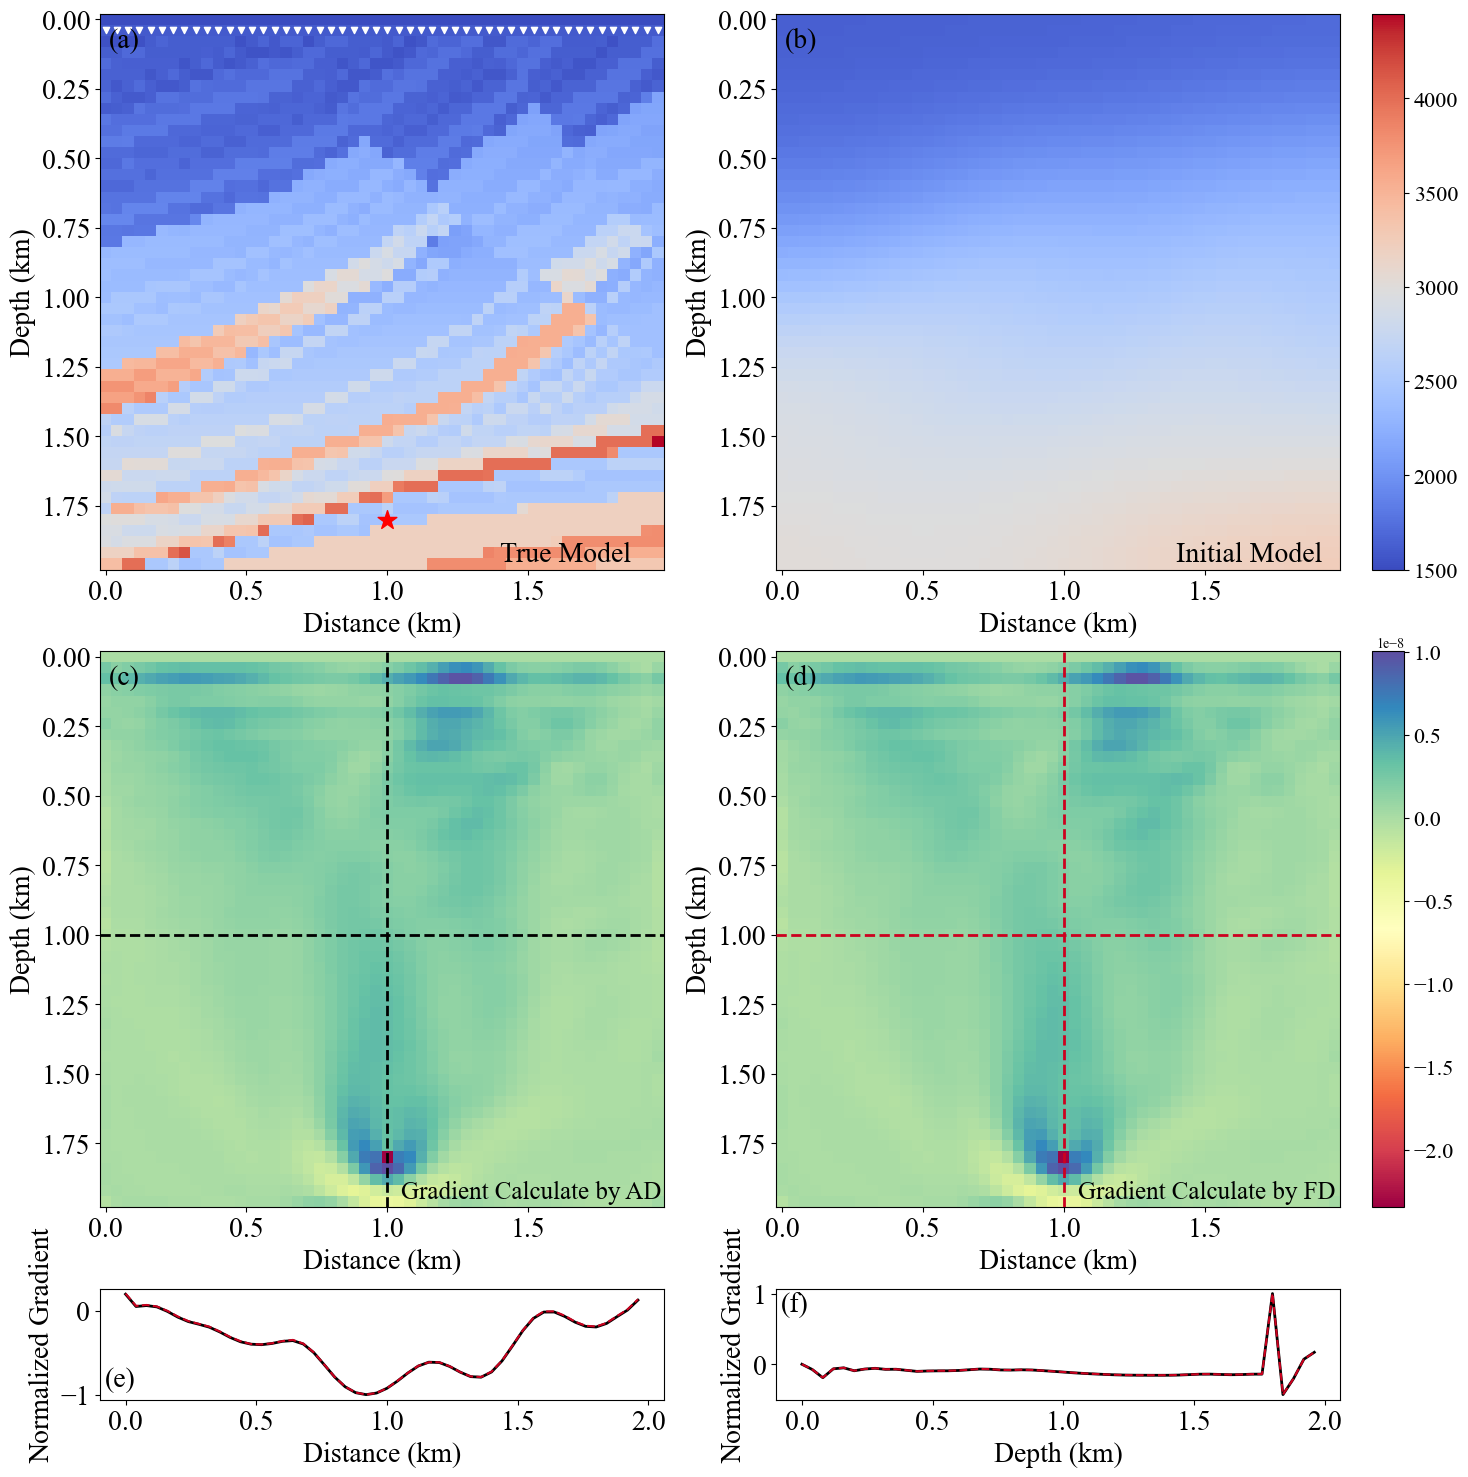

In [16]:
def add_right_cax(ax, pad, width):
    axpos = ax.get_position()
    caxpos = matplotlib.transforms.Bbox.from_extents(
        axpos.x1 + pad,
        axpos.y0,
        axpos.x1 + pad + width,
        axpos.y1
    )
    cax = ax.figure.add_axes(caxpos)

    return cax

cmap = "coolwarm"

fig, axs = plt.subplots(
    3, 2, gridspec_kw={"width_ratios": [1,1], "height_ratios": [5,5, 1]},figsize=(16,18)
)
axs[0][0].pcolormesh(z_mesh,x_mesh,vp_true,cmap=cmap,vmin=vp_true.min(),vmax=vp_true.max())
axs[0][0].scatter(rcv_x/1000,rcv_z/1000,c='w',marker="v",s=20)
axs[0][0].scatter(src_x/1000,src_z/1000,c='r',marker="*",s=200)
axs[0][0].invert_yaxis()
axs[0][0].tick_params(labelsize = 20)
axs[0][0].set_ylabel("Depth (km)",fontsize=20)
axs[0][0].set_xlabel("Distance (km)",fontsize=20)
axs[0][0].text(1.4,1.95,"True Model",c='k',fontsize=20)

im1 = axs[0][1].pcolormesh(z_mesh,x_mesh,vp_init,cmap=cmap,vmin=vp_true.min(),vmax=vp_true.max())
axs[0][1].invert_yaxis()
axs[0][1].tick_params(labelsize = 20)
axs[0][1].set_ylabel("Depth (km)",fontsize=20)
axs[0][1].set_xlabel("Distance (km)",fontsize=20)
axs[0][1].text(1.4,1.95,"Initial Model",c='k',fontsize=20)


cmap = "Spectral"

cax1 = add_right_cax(axs[0][1], pad=0.02, width=0.02)
cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.ax.tick_params(labelsize=16)

axs[1][0].pcolormesh(z_mesh,x_mesh,adfwi_grad,cmap=cmap)
axs[1][0].axvline(x = 25*dx/1000,c='k',linestyle="--",linewidth=2,zorder=10)
axs[1][0].axhline(y = 25*dx/1000,c='k',linestyle="--",linewidth=2,zorder=10)
axs[1][0].invert_yaxis()
axs[1][0].tick_params(labelsize = 20)
axs[1][0].set_ylabel("Depth (km)",fontsize=20)
axs[1][0].set_xlabel("Distance (km)",fontsize=20)
axs[1][0].text(1.05,1.95,"Gradient Calculate by AD",c='k',fontsize=18,zorder=20)

im2 = axs[1][1].pcolormesh(z_mesh,x_mesh,-perturbation_grad,cmap=cmap)
axs[1][1].axvline(x = 25*dx/1000,c='#CC011F',linestyle="--",linewidth=2,zorder=10)
axs[1][1].axhline(y = 25*dx/1000,c='#CC011F',linestyle="--",linewidth=2,zorder=10)
axs[1][1].invert_yaxis()
axs[1][1].tick_params(labelsize = 20)
axs[1][1].set_ylabel("Depth (km)",fontsize=20)
axs[1][1].set_xlabel("Distance (km)",fontsize=20)
axs[1][1].text(1.05,1.95,"Gradient Calculate by FD",c='k',fontsize=18,zorder=10)

cax2 = add_right_cax(axs[1][1], pad=0.02, width=0.02)
cbar2 = fig.colorbar(im2, cax=cax2)
cbar2.ax.tick_params(labelsize=16)

index = 25
adswit_acoustic_grad_single = -adfwi_grad[index,:]/3000/4
perturb_grad_single = perturbation_grad[index,:]
diff1 = adswit_acoustic_grad_single/np.max(np.abs(adswit_acoustic_grad_single)) - perturb_grad_single/np.max(np.abs(perturb_grad_single))
axs[2][0].plot(np.arange(len(perturb_grad_single))*dx/1000,adswit_acoustic_grad_single/np.max(np.abs(adswit_acoustic_grad_single)),c='k',linewidth=2,label="AD")
axs[2][0].plot(np.arange(len(perturb_grad_single))*dx/1000,perturb_grad_single/np.max(np.abs(perturb_grad_single)), c='#CC011F',linestyle="--",label="Numerical")
axs[2][0].tick_params(labelsize = 20)
axs[2][0].tick_params(labelsize = 20)
axs[2][0].set_ylabel("Normalized Gradient",fontsize=20)
axs[2][0].set_xlabel("Distance (km)",fontsize=20)

adswit_acoustic_grad_single = -adfwi_grad[:,index]/3000/4
perturb_grad_single = perturbation_grad[:,index]
diff1 = adswit_acoustic_grad_single/np.max(np.abs(adswit_acoustic_grad_single)) - perturb_grad_single/np.max(np.abs(perturb_grad_single))
axs[2][1].plot(np.arange(len(perturb_grad_single))*dx/1000,adswit_acoustic_grad_single/np.max(np.abs(adswit_acoustic_grad_single)),c='k',linewidth=2,label="AD")
axs[2][1].plot(np.arange(len(perturb_grad_single))*dx/1000,perturb_grad_single/np.max(np.abs(perturb_grad_single)),
            c='#CC011F',linestyle="--",label="Numerical")
axs[2][1].tick_params(labelsize = 20)
axs[2][1].tick_params(labelsize = 20)
axs[2][1].set_ylabel("Normalized Gradient",fontsize=20)
axs[2][1].set_xlabel("Depth (km)",fontsize=20)

axs[0][0].text(0.01,0.1,"(a)",c='k',fontsize=20)
axs[0][1].text(0.01,0.1,"(b)",c='k',fontsize=20)
axs[1][0].text(0.01,0.1,"(c)",c='k',fontsize=20)
axs[1][1].text(0.01,0.1,"(d)",c='k',fontsize=20)
axs[2][0].text(-0.08,-0.9,"(e)",c='k',fontsize=20)
axs[2][1].text(-0.08, 0.75,"(f)",c='k',fontsize=20)

plt.savefig("./data/Figure_S1_acoustic_Gradient_Cmp.png",bbox_inches="tight",dpi=300)
plt.show()